**Import Required Libraries**

In [3]:

# Import Required Libraries


# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save Model
import joblib

**Upload Dataset**

In [4]:

# Upload Dataset


from google.colab import files

uploaded = files.upload()

Saving manufacturing_dataset_1000_samples.csv to manufacturing_dataset_1000_samples (1).csv


**Read Dataset**

In [5]:

# Read Dataset

df = pd.read_csv("manufacturing_dataset_1000_samples.csv")

# Display first five rows
df.head()

,Timestamp,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
0,2023-01-01 00:00:00,221.0,136.0,28.7,13.6,375.5,28.0,3.8,11.2,64,Evening,Type_B,Economy,Thursday,1.625,42.3,0.063,0.510,36.5
1,2023-01-01 01:00:00,213.3,128.9,34.5,14.0,215.8,22.6,6.8,6.3,58,Night,Type_A,Standard,Wednesday,1.655,48.5,0.037,0.389,29.9
2,2023-01-01 02:00:00,222.8,115.9,19.9,9.5,307.0,25.3,4.2,9.6,47,Day,Type_A,Standard,Monday,1.922,29.4,0.061,0.551,56.9
3,2023-01-01 03:00:00,233.3,105.3,39.2,13.1,137.8,26.0,9.2,8.6,49,Evening,Type_A,Premium,Saturday,2.215,52.3,0.054,0.293,31.0
4,2023-01-01 04:00:00,212.2,125.5,45.0,9.9,298.2,23.6,6.2,23.0,49,Night,Type_B,Premium,Monday,1.691,54.9,0.145,0.443,15.0


**Basic Information**

In [6]:

# Dataset Information


print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nInformation:")
df.info()

Shape of Dataset:
(1000, 19)

Column Names:
Index(['Timestamp', 'Injection_Temperature', 'Injection_Pressure',
       'Cycle_Time', 'Cooling_Time', 'Material_Viscosity',
       'Ambient_Temperature', 'Machine_Age', 'Operator_Experience',
       'Maintenance_Hours', 'Shift', 'Machine_Type', 'Material_Grade',
       'Day_of_Week', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time',
       'Efficiency_Score', 'Machine_Utilization', 'Parts_Per_Hour'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Timestamp                   1000 non-null   object 
 1   Injection_Temperature       1000 non-null   float64
 2   Injection_Pressure          1000 non-null   float64
 3   Cycle_Time                  1000 non-null   float64
 4   Cooling_Time                1000 non-null   float64
 5   Mate

**Statistical Summary**

In [7]:

# Statistical Summary

df.describe()

,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
count,1000.000000,1000.000000,1000.00000,1000.00000,980.000000,980.000000,1000.000000,980.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,215.315900,116.075000,35.85170,11.92320,251.630714,22.941224,7.855900,30.795204,50.580000,1.885852,47.737000,0.192688,0.356844,29.298100
std,11.995507,14.667246,8.35349,2.30429,73.348695,2.773712,3.900798,27.684769,16.014558,0.274323,8.671153,0.173839,0.195610,11.955497
min,180.000000,80.000000,16.30000,8.00000,104.600000,18.000000,1.000000,1.000000,26.000000,1.286000,24.600000,0.006000,0.001000,5.000000
25%,207.200000,105.900000,28.80000,10.27500,200.900000,20.800000,4.700000,9.800000,45.000000,1.683750,41.000000,0.061000,0.193000,17.500000
50%,215.300000,115.950000,36.85000,11.90000,242.700000,22.900000,7.900000,22.100000,50.000000,1.849500,48.550000,0.139000,0.355500,28.200000
75%,222.800000,125.925000,45.00000,13.50000,295.300000,25.100000,11.100000,43.425000,55.000000,2.044250,55.300000,0.274000,0.520000,38.000000
max,300.000000,150.000000,60.00000,19.90000,1000.000000,28.000000,15.000000,120.000000,500.000000,2.843000,64.900000,0.840000,0.755000,68.600000


**Check Missing Values**

In [8]:

# Missing Values

print(df.isnull().sum())

Timestamp                      0
Injection_Temperature          0
Injection_Pressure             0
Cycle_Time                     0
Cooling_Time                   0
Material_Viscosity            20
Ambient_Temperature           20
Machine_Age                    0
Operator_Experience           20
Maintenance_Hours              0
Shift                          0
Machine_Type                   0
Material_Grade                 0
Day_of_Week                    0
Temperature_Pressure_Ratio     0
Total_Cycle_Time               0
Efficiency_Score               0
Machine_Utilization            0
Parts_Per_Hour                 0
dtype: int64


**Check Duplicate Rows**

In [9]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

# Remove duplicate rows if any

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Duplicate Rows: 0
Shape after removing duplicates: (1000, 19)


**Drop Timestamp Column**

In [10]:

# Drop Timestamp


if 'Timestamp' in df.columns:
    df.drop('Timestamp', axis=1, inplace=True)

print(df.head())

   Injection_Temperature  Injection_Pressure  Cycle_Time  Cooling_Time  \
0                  221.0               136.0        28.7          13.6   
1                  213.3               128.9        34.5          14.0   
2                  222.8               115.9        19.9           9.5   
3                  233.3               105.3        39.2          13.1   
4                  212.2               125.5        45.0           9.9   

   Material_Viscosity  Ambient_Temperature  Machine_Age  Operator_Experience  \
0               375.5                 28.0          3.8                 11.2   
1               215.8                 22.6          6.8                  6.3   
2               307.0                 25.3          4.2                  9.6   
3               137.8                 26.0          9.2                  8.6   
4               298.2                 23.6          6.2                 23.0   

   Maintenance_Hours    Shift Machine_Type Material_Grade Day_of_Week  \
0

**Handle Missing Values**

In [11]:
# Check missing values
print(df.isnull().sum())

# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numerical missing values with mean
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical missing values with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Check again
print(df.isnull().sum())

Injection_Temperature          0
Injection_Pressure             0
Cycle_Time                     0
Cooling_Time                   0
Material_Viscosity            20
Ambient_Temperature           20
Machine_Age                    0
Operator_Experience           20
Maintenance_Hours              0
Shift                          0
Machine_Type                   0
Material_Grade                 0
Day_of_Week                    0
Temperature_Pressure_Ratio     0
Total_Cycle_Time               0
Efficiency_Score               0
Machine_Utilization            0
Parts_Per_Hour                 0
dtype: int64
Injection_Temperature         0
Injection_Pressure            0
Cycle_Time                    0
Cooling_Time                  0
Material_Viscosity            0
Ambient_Temperature           0
Machine_Age                   0
Operator_Experience           0
Maintenance_Hours             0
Shift                         0
Machine_Type                  0
Material_Grade                0
Day_of_We

**Encode Categorical Variables**

In [12]:
# Convert categorical columns into numerical values

df = pd.get_dummies(
    df,
    columns=['Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week'],
    drop_first=True
)

# Display first five rows
df.head()

,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Temperature_Pressure_Ratio,...,Machine_Type_Type_B,Machine_Type_Type_C,Material_Grade_Premium,Material_Grade_Standard,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday
0,221.0,136.0,28.7,13.6,375.5,28.0,3.8,11.2,64,1.625,...,True,False,False,False,False,False,False,True,False,False
1,213.3,128.9,34.5,14.0,215.8,22.6,6.8,6.3,58,1.655,...,False,False,False,True,False,False,False,False,False,True
2,222.8,115.9,19.9,9.5,307.0,25.3,4.2,9.6,47,1.922,...,False,False,False,True,True,False,False,False,False,False
3,233.3,105.3,39.2,13.1,137.8,26.0,9.2,8.6,49,2.215,...,False,False,True,False,False,True,False,False,False,False
4,212.2,125.5,45.0,9.9,298.2,23.6,6.2,23.0,49,1.691,...,True,False,True,False,True,False,False,False,False,False


**Correlation Heatmap**

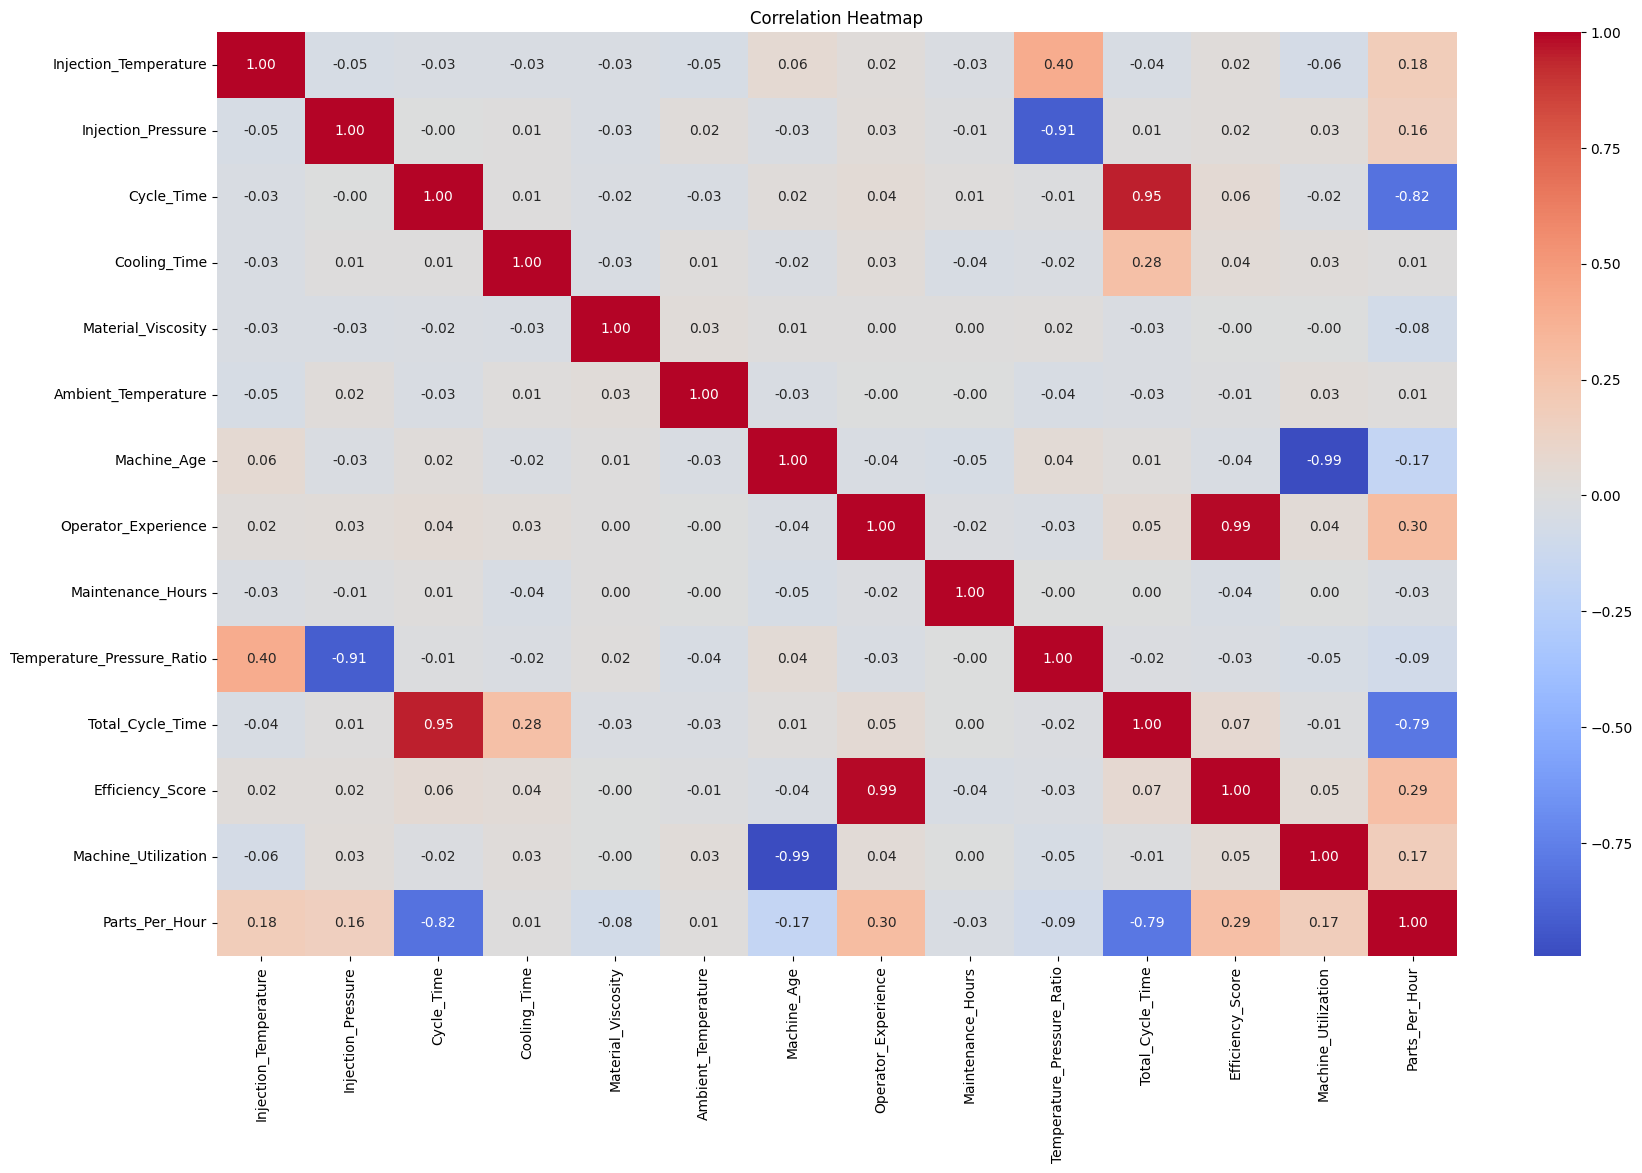

In [13]:
# Plot correlation heatmap

plt.figure(figsize=(20,12))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,      # Show correlation values
    fmt=".2f",       # Display 2 decimal places
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

**Distribution Plot**

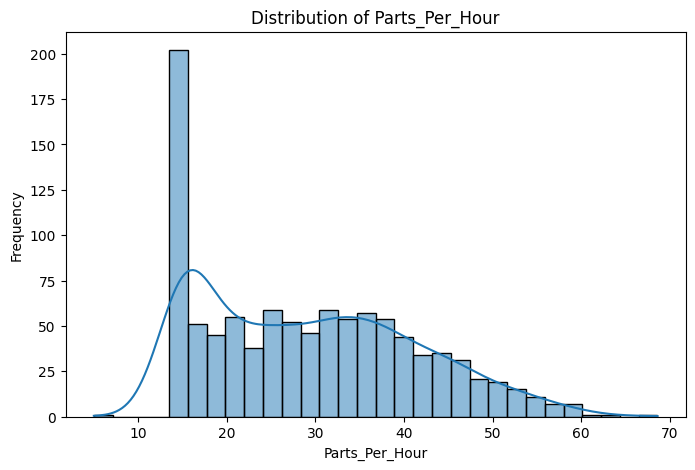

In [14]:
# Plot distribution of target variable

plt.figure(figsize=(8,5))

sns.histplot(df["Parts_Per_Hour"], bins=30, kde=True)

plt.title("Distribution of Parts_Per_Hour")
plt.xlabel("Parts_Per_Hour")
plt.ylabel("Frequency")

plt.show()

**Boxplot**

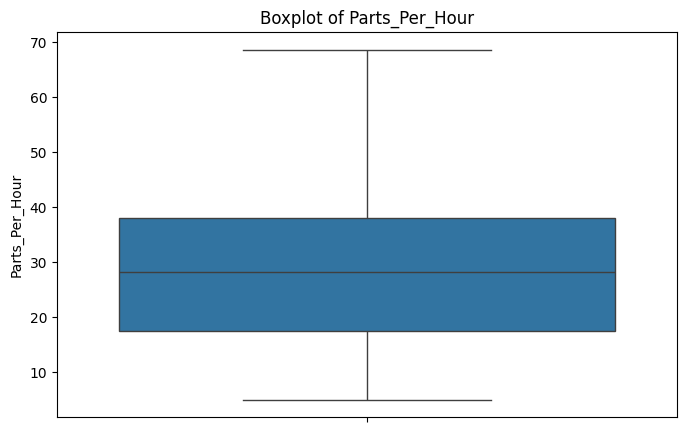

In [15]:
# Plot boxplot to check outliers

plt.figure(figsize=(8,5))

sns.boxplot(y=df["Parts_Per_Hour"])

plt.title("Boxplot of Parts_Per_Hour")

plt.show()

**Pairplot (Optional but Recommended for EDA)**

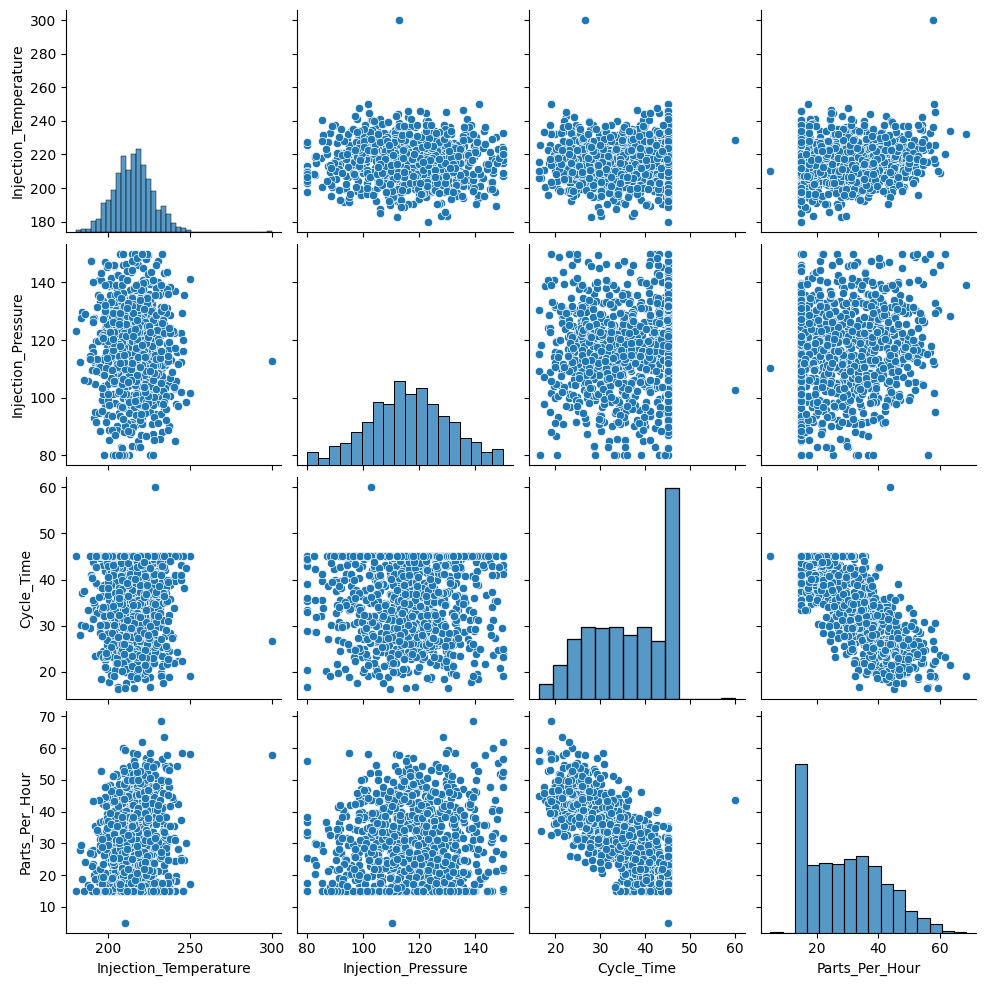

In [16]:
# Plot pairplot for selected numerical features

columns = [
    "Injection_Temperature",
    "Injection_Pressure",
    "Cycle_Time",
    "Parts_Per_Hour"
]

sns.pairplot(df[columns])

plt.show()

**Separate Features and Target**

In [17]:
# Separate input features and target variable

X = df.drop("Parts_Per_Hour", axis=1)

y = df["Parts_Per_Hour"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1000, 25)
Target Shape : (1000,)


**Train-Test Split**

In [18]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)

print("Testing Data :", X_test.shape)

Training Data : (800, 25)
Testing Data : (200, 25)


**Feature Scaling**

In [19]:
# Scale the features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


**Train Linear Regression Model**

In [20]:
# Create Linear Regression model

model = LinearRegression()

# Train the model

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


**Predict Test Data**

In [21]:
# Predict the output

y_pred = model.predict(X_test)

print("First 10 Predictions")

print(y_pred[:10])

First 10 Predictions
[19.90502763 44.40354276 34.06221681 39.71238622 18.38667628 20.4370332
 33.52988815 14.11935201 27.97047624 32.32955988]


**Evaluate the Model**

In [22]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)

Mean Absolute Error : 2.7157288381643307
Mean Squared Error : 12.280335100794233
Root Mean Squared Error : 3.5043309062921315
R2 Score : 0.9058926590665997


**Actual vs Predicted Table**

In [23]:
# Compare actual and predicted values

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,18.6,19.905028
1,42.8,44.403543
2,34.2,34.062217
3,40.0,39.712386
4,15.0,18.386676
5,15.0,20.437033
6,33.6,33.529888
7,15.0,14.119352
8,25.0,27.970476
9,24.2,32.329560


**Actual vs Predicted Plot**

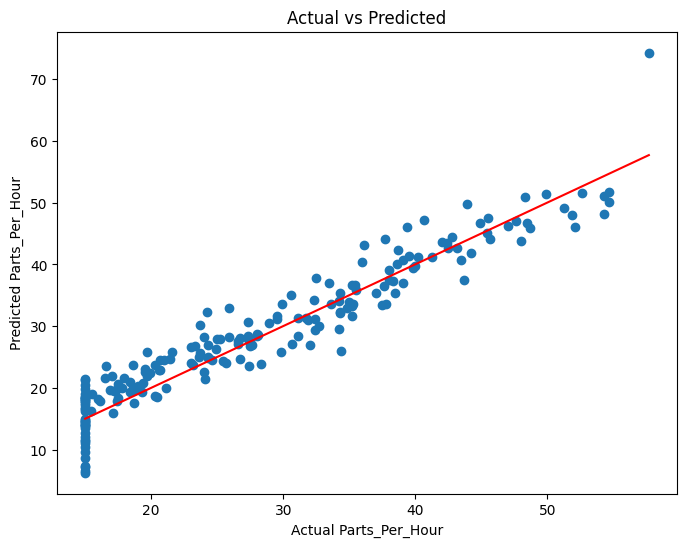

In [24]:
# Plot Actual vs Predicted values

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Parts_Per_Hour")
plt.ylabel("Predicted Parts_Per_Hour")

plt.title("Actual vs Predicted")

plt.show()

**Residual Plot**


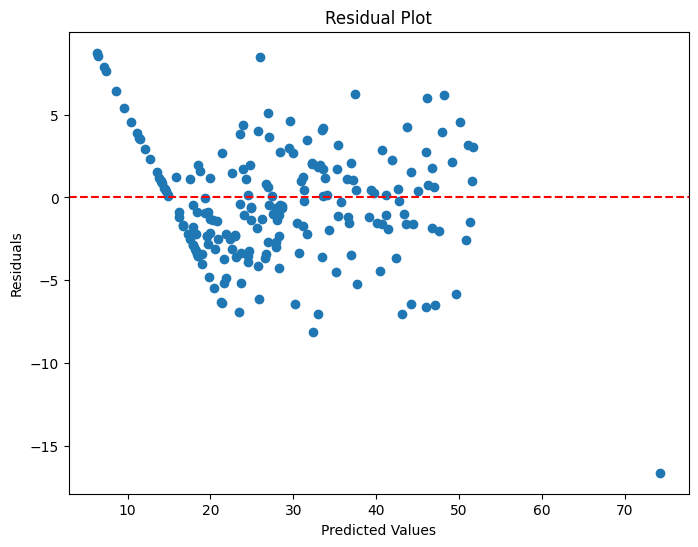

In [25]:
# Plot residuals

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

**Save the Model**

In [26]:
# Save the trained model

joblib.dump(model, "linear_regression_model.pkl")

print("Model saved successfully.")

Model saved successfully.


**app.py**

In [27]:
%%writefile app.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np

app = FastAPI(title="Manufacturing Equipment Output Prediction API")

model = joblib.load("linear_regression_model.pkl")

class InputData(BaseModel):
    features: list

@app.get("/")
def home():
    return {"message": "Manufacturing Equipment Output Prediction API is Running Successfully!"}

@app.post("/predict")
def predict(data: InputData):
    input_data = np.array(data.features).reshape(1, -1)
    prediction = model.predict(input_data)
    return {"Predicted Parts Per Hour": float(prediction[0])}

Writing app.py


**requirements.txt**

In [28]:
%%writefile requirements.txt
fastapi
uvicorn
pyngrok
nest_asyncio
joblib
numpy
pandas
scikit-learn
pydantic

Writing requirements.txt


**Dockerfile**

In [29]:
%%writefile Dockerfile
FROM python:3.10

WORKDIR /app

COPY . .

RUN pip install -r requirements.txt

EXPOSE 8000

CMD ["uvicorn","app:app","--host","0.0.0.0","--port","8000"]

Writing Dockerfile


**Install libraries**

In [30]:
!pip install fastapi uvicorn pyngrok nest_asyncio

In [31]:
import nest_asyncio
nest_asyncio.apply()

**Add ngrok Authtoken**

In [32]:
from pyngrok import ngrok

ngrok.set_auth_token("3FaehN1sEQ9MQC6vFyl8Ws5iNft_7mVPAk7knm91JcXAoRwcj")

**Start FastAPI**

In [33]:
import subprocess
import time

process = subprocess.Popen(
    ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
)

time.sleep(5)

print("FastAPI Started Successfully")

FastAPI Started Successfully


In [34]:
!curl http://127.0.0.1:8000

{"message":"Manufacturing Equipment Output Prediction API is Running Successfully!"}

**ngrok URL**

In [35]:
from pyngrok import ngrok

public_url = ngrok.connect(8000)

print(public_url)

NgrokTunnel: "https://superbowl-glitzy-contest.ngrok-free.dev" -> "http://localhost:8000"


**ZIP file**

In [36]:
!zip Manufacturing_Project.zip app.py Dockerfile requirements.txt linear_regression_model.pkl

  adding: app.py (deflated 45%)
  adding: Dockerfile (deflated 12%)
  adding: requirements.txt (deflated 13%)
  adding: linear_regression_model.pkl (deflated 9%)


**Download ZIP**

In [37]:
from google.colab import files

files.download("Manufacturing_Project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>